# Project Vacatures
---
## Inleiding

In dit project maak ik een dataset met vacatures geprepareerd en opgeschoond met als doel om een bruikbare dataset te genereren voor het analyse team. Zodat zij inzicht krijgen in de vacatures die nu rongaan. De data is afkomstig van de Adzuna API en bevat informatie over functietitels, categorieën, locaties en salarissen.

Omdat de ruwe data veel ontbrekende en inconsistente waarden bevat, ga ik in dit notebook uitgebreid aandacht besteden aan data quality checks en data cleaning. Hierbij worden onder andere categorieën opgeschoond, ontbrekende salariswaarden aangevuld en categorieën zonder salarisinformatie geïdentificeerd.

Vervolgens wordt per categorie onderzocht welke salariswaarden significant afwijken door middel van outlier-detectie. Hiervoor wordt gebruikgemaakt van zowel statistische methoden (IQR) als een machine learning-model (IsolationForest). Door de analyse per categorie uit te voeren, wordt rekening gehouden met verschillen tussen functietypes en salarisniveaus.

## Importeren van libraries

Als eerste worden de benodigde Python-libraries geïmporteerd. Ik maak gebruik van libraries om bijvoorbeeld de data in te laden, visualiseren en sklearn voor het Isolation Forest model.

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from sklearn.ensemble import IsolationForest

## Data inladen

De dataset (CSV-bestand) wordt met vacatures ingelezen in een pandas DataFrame (`pd`).
De data is afkomstig van een live API en is vooraf opgeslagen in een CSV-bestand. Met behulp van `head()` wordt een eerste indruk van de dataset verkregen en wordt gecontroleerd of de juiste data correct is ingeladen.

In [26]:
df = pd.read_csv("vacatures2.csv")
df.head(10)

,title,company,location,category,salary_min,salary_max,created
0,Tankwagenreiniger,NaN,"Oss, Noord-Brabant",Unknown,30000.0,36000.0,2025-07-03T13:26:05Z
1,Vrachtwagenchauffeur bouwmaterialen omgeving V...,NaN,"Vianen, Provincie Utrecht",Unknown,30000.0,36000.0,2025-07-03T13:26:14Z
2,Schoonmaakmedewerker regio Uden,NaN,"Uden, Noord-Brabant",Unknown,NaN,NaN,2025-07-03T13:26:08Z
3,Logistiek medewerker,NaN,"Gilze, Gilze en Rijen",Unknown,30000.0,36000.0,2025-07-03T13:26:07Z
4,Verkoopmedewerker,NaN,"Schijndel, Noord-Brabant",Unknown,24000.0,30000.0,2025-07-03T13:26:13Z
5,Monteur / Autotechnicus Inbouw,NaN,"Tilburg, Noord-Brabant",Unknown,30000.0,36000.0,2025-07-03T13:26:11Z
6,Safety Engineer,NaN,"'s-Hertogenbosch, Noord-Brabant",Unknown,NaN,NaN,2025-07-03T13:26:14Z
7,Medewerker Vormerij,NaN,"Helmond, Noord-Brabant",Unknown,36000.0,42000.0,2025-11-17T21:35:58Z
8,Bezorger automaterialen Almere,NaN,"Almere, Flevoland",Unknown,24000.0,24000.0,2025-10-15T20:05:19Z
9,Reachtruck Driver,NaN,"Moerdijk, Noord-Brabant",Unknown,NaN,NaN,2025-09-10T18:05:38Z


**Observatie:**
Je kan nu duidelijk zien dat de vacatures niet altijd even mooi zijn ingevult. Er zijn veel NaN waardes en de locaties zijn gemeente en soms een provincie of een stad. De Functietitels hebben vaak extra tekens zoals `()`, `/` of `-`. Ook zijn er veel unknown waardes in `Category` daar ga ik nu verder naar kijken.

### Data quality checks en eerste verkenning van categorieën

In deze stap wordt de verdeling van vacatures per categorie onderzocht. Door het aantal vacatures per categorie te tellen, ontstaat een eerste inzicht in de kwaliteit en verdeling van deze kolom.

In [27]:
Waardes_per_category = df['category'].value_counts().head(10)
Waardes_per_category

category
Unknown                               523
Vacatures Ander of Algemeen           100
Logistieke vacatures                   87
Sales vacatures                        46
Bouwkunde vacatures                    43
IT ICT vacatures                       38
Horeca en Catering vacatures           35
Adviseur en Consultancy vacatures      30
Klantenservice vacatures               23
Accounting en Financiële vacatures     19
Name: count, dtype: int64

**Observatie:**
Uit de resultaten blijkt dat een groot deel van de vacatures de waarde `unknown` en `Vacatures Ander of Algemeen` bevat. Daarnaast zijn de meeste categorieën slechts een relatief klein aantal vacatures. Dit geeft een eerste indicatie van mogelijke datakwaliteitsproblemen binnen de categorie-kolom.

**Data frame copy:**
Copy maken om mogelijk later goed de verschillen te kunnen zien.

In [28]:
df_before = df.copy()

### Opschonen van de Category-kolom

In deze stap wordt de kolom `category` opgeschoond. Vacatures waarbij de categorie`unknown` of (`NaN`) zijn worden aangepast. Als oplossing pak ik de waarde uit de kolom `title`, omdat de functietitel in de meeste gevallen de genoeg informatie bevat om een geschikte categorie af te leiden.

Ik heb net gezien dat somige functietitels vaak extra tekens zoals `()`, `/` of `-` bevatten. Deze wil ik met behulp van Regex er uit filteren. Daarna wordt de tekst opgeschoond door gebruik te maken van `strip`, `lower` en `title`, zodat alle categorieën een consistente en duidelijke opmaak hebben.

In [ ]:
strip = df['category'].str.strip().str.lower().isin(['unknown', 'vacatures ander of algemeen'])
df.loc[strip, 'category'] = df.loc[strip, 'title']

def clean_title(title):
    if pd.isna(title):
        return title
    return re.split(r'\s[-–—|/]\s|\(|\\', title)[0].strip()

df['category'] = df['category'].apply(clean_title)
df['category'] = (df['category'].str.strip().str.lower().str.title())

display(df.head(15))

,title,company,location,category,salary_min,salary_max,created
0,Tankwagenreiniger,NaN,"Oss, Noord-Brabant",Tankwagenreiniger,30000.0,36000.0,2025-07-03T13:26:05Z
1,Vrachtwagenchauffeur bouwmaterialen omgeving V...,NaN,"Vianen, Provincie Utrecht",Vrachtwagenchauffeur Bouwmaterialen Omgeving V...,30000.0,36000.0,2025-07-03T13:26:14Z
2,Schoonmaakmedewerker regio Uden,NaN,"Uden, Noord-Brabant",Schoonmaakmedewerker Regio Uden,NaN,NaN,2025-07-03T13:26:08Z
3,Logistiek medewerker,NaN,"Gilze, Gilze en Rijen",Logistiek Medewerker,30000.0,36000.0,2025-07-03T13:26:07Z
4,Verkoopmedewerker,NaN,"Schijndel, Noord-Brabant",Verkoopmedewerker,24000.0,30000.0,2025-07-03T13:26:13Z
5,Monteur / Autotechnicus Inbouw,NaN,"Tilburg, Noord-Brabant",Monteur,30000.0,36000.0,2025-07-03T13:26:11Z
6,Safety Engineer,NaN,"'s-Hertogenbosch, Noord-Brabant",Safety Engineer,NaN,NaN,2025-07-03T13:26:14Z
7,Medewerker Vormerij,NaN,"Helmond, Noord-Brabant",Medewerker Vormerij,36000.0,42000.0,2025-11-17T21:35:58Z
8,Bezorger automaterialen Almere,NaN,"Almere, Flevoland",Bezorger Automaterialen Almere,24000.0,24000.0,2025-10-15T20:05:19Z
9,Reachtruck Driver,NaN,"Moerdijk, Noord-Brabant",Reachtruck Driver,NaN,NaN,2025-09-10T18:05:38Z


### Vergelijking van categorieën vóór en na opschonen

Om dubbel te controleren of het alles goed is gegaan van het opschonen van de `category` kolom is, worden de aantallen vacatures per categorie voor en na de cleaning vergeleken. Zodat het zichtbaar wordt welke categorieën zijn veranderd/toegevoegd.

In [ ]:
counts_before = df_before['category'].value_counts()
counts_after = df['category'].value_counts()

comparison = (
    pd.concat([counts_before, counts_after], axis=1, keys=['before', 'after']).fillna(0).astype(int)
)

comparison['difference'] = comparison['after'] - comparison['before']
display(comparison.sort_values('difference', ascending=False).head(25))

,before,after,difference
category,,,
Logistieke Vacatures,0,87,87
Sales Vacatures,0,46,46
Bouwkunde Vacatures,0,43,43
It Ict Vacatures,0,38,38
Horeca En Catering Vacatures,0,35,35
Adviseur En Consultancy Vacatures,0,30,30
Klantenservice Vacatures,0,23,23
Tandarts,0,22,22
Accounting En Financiële Vacatures,0,19,19


**Observatie:**
Uit deze vergelijking blijkt duidelijk welke categorieën zijn aangepast, vervangen of toegevoegd. Categorieën die eerst `unknown` waren, zijn nu vervangen door waarden van de functietitel.  
Nu kan ik goed zien dat deze cleaning heeft gewerkt zoals bedoeld.

---

## Kijken hoe de totale waardes per category er nu uit zien

In [ ]:
display(df['category'].value_counts().head(25))

category
Logistieke Vacatures                                                 87
Sales Vacatures                                                      46
Bouwkunde Vacatures                                                  43
It Ict Vacatures                                                     38
Horeca En Catering Vacatures                                         35
Adviseur En Consultancy Vacatures                                    30
Klantenservice Vacatures                                             23
Tandarts                                                             22
Accounting En Financiële Vacatures                                   19
Tandartsassistent                                                    19
Preventieassistent                                                   16
Pr Reclame En Marketing Vacatures                                    15
Dutch-Speaking Customer Support                                      12
Mondhygiënist                                          

## Salarisinformatie opschonen en aanvullen

In dit blok worden de salariskolommen opgeschoond en aangevuld, omdat er veel ontbrekende waarden zijn.
Doordat de verschillende vacatures op verschillende manieren worden ingevuld (salaris per uur, per maand, per jaar) converteer ik dit om salaris per jaar aan te houden.
Omdat er veel verschillende categorieën zijn, wordt de mediaan per categorie gebruikt om de ontbrekende waarden in te vullen in plaats van de mediaan van de gehele dataset.
Voor elke vacature wordt het gemiddelde salaris `salary_row_mean` berekend op basis van `salary_min` en `salary_max`.  
Het gemiddelde salaris per categorie `salary_mean` bepaald en waar nodig aangevuld met het gemiddelde.

In [ ]:
# Kolommen salary_min en salary_max naar numeriek converteren (fouten negeren)
df["salary_min"] = pd.to_numeric(df["salary_min"], errors="coerce")
df["salary_max"] = pd.to_numeric(df["salary_max"], errors="coerce")

# Doordat de verschillende vacatures op verschillende manieren worden ingevuld (salaris per uur, per maand, per jaar) converteer ik dit om salaris per jaar aan te houden.
def convert_to_year(salary):
    if pd.isna(salary):
        return salary
    if salary < 100:
        return salary * 40 * 52
    elif salary < 800:
        return salary * 21 * 12
    elif salary < 8000:
        return salary * 12
    return salary

# convert min en max salaris naar jaarloon
df["salary_min"] = df["salary_min"].apply(convert_to_year)
df["salary_max"] = df["salary_max"].apply(convert_to_year)

# min en max waarden definiëren om te bepalen wat een realistisch salaris is
MIN_YEARLY = 15000   # Gebaseert op minimaal jaarloon in Nederland
MAX_YEARLY = 250000  # Gebaseert op wat realistisch is

# Onrealistische waarden (bvb 5 euro per jaar of 500.000 euro per jaar) omzetten naar NaN
df.loc[df["salary_min"] < MIN_YEARLY, "salary_min"] = np.nan
df.loc[df["salary_max"] > MAX_YEARLY, "salary_max"] = np.nan

# Als het minimum hoger is dan het maximum klopt er iets niet en dan allebei NaN maken
df.loc[df["salary_min"] > df["salary_max"], ["salary_min", "salary_max"]] = np.nan

# Bijhouden welke rijen origineel salaris hadden en welke niet, zodat ik later kan filteren op rijen die echt bruikbaar zijn
df["has_original_salary"] = df["salary_min"].notna() | df["salary_max"].notna()

# Functie om NaN-waarden in te vullen met de mediaan van de categorie
def fill_with_category_median(series):
    return series.fillna(series.median())

# Alleen de rijen opvullen waar ik geen origineel salaris voor heb (om te voorkomen dat ik echte waarden overschrijf)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    df["salary_min_filled"] = (
    df.groupby("category")["salary_min"].transform(fill_with_category_median)
    )

    df["salary_max_filled"] = (
    df.groupby("category")["salary_max"].transform(fill_with_category_median)
    )

display(df.head(25))

,title,company,location,category,salary_min,salary_max,created,has_original_salary,salary_min_filled,salary_max_filled
0,Tankwagenreiniger,NaN,"Oss, Noord-Brabant",Tankwagenreiniger,30000.0,36000.0,2025-07-03T13:26:05Z,True,30000.0,36000.0
1,Vrachtwagenchauffeur bouwmaterialen omgeving V...,NaN,"Vianen, Provincie Utrecht",Vrachtwagenchauffeur Bouwmaterialen Omgeving V...,30000.0,36000.0,2025-07-03T13:26:14Z,True,30000.0,36000.0
2,Schoonmaakmedewerker regio Uden,NaN,"Uden, Noord-Brabant",Schoonmaakmedewerker Regio Uden,NaN,NaN,2025-07-03T13:26:08Z,False,NaN,NaN
3,Logistiek medewerker,NaN,"Gilze, Gilze en Rijen",Logistiek Medewerker,30000.0,36000.0,2025-07-03T13:26:07Z,True,30000.0,36000.0
4,Verkoopmedewerker,NaN,"Schijndel, Noord-Brabant",Verkoopmedewerker,24000.0,30000.0,2025-07-03T13:26:13Z,True,24000.0,30000.0
5,Monteur / Autotechnicus Inbouw,NaN,"Tilburg, Noord-Brabant",Monteur,30000.0,36000.0,2025-07-03T13:26:11Z,True,30000.0,36000.0
6,Safety Engineer,NaN,"'s-Hertogenbosch, Noord-Brabant",Safety Engineer,NaN,NaN,2025-07-03T13:26:14Z,False,NaN,NaN
7,Medewerker Vormerij,NaN,"Helmond, Noord-Brabant",Medewerker Vormerij,36000.0,42000.0,2025-11-17T21:35:58Z,True,36000.0,42000.0
8,Bezorger automaterialen Almere,NaN,"Almere, Flevoland",Bezorger Automaterialen Almere,24000.0,24000.0,2025-10-15T20:05:19Z,True,24000.0,24000.0
9,Reachtruck Driver,NaN,"Moerdijk, Noord-Brabant",Reachtruck Driver,NaN,NaN,2025-09-10T18:05:38Z,False,NaN,NaN


**Observatie:**  Na het vullen van de NaN-waarden met het gemiddelde per categorie, zijn de meeste ontbrekende waarden ingevuld.  
Sommige categorieën bevatten te weinig data, waardoor er nog steeds NaN-waarden aanwezig zijn.  
Het zou niet verstandig zijn om deze resterende NaN-waarden op te vullen met de mediaan van de hele dataset, omdat de salarissen per vacature sterk kunnen verschillen. Dit zou de nauwkeurigheid van de data verminderen.

Omdat er best veel waardes `Nan` zijn probeerd NumPy het gemiddelde van een lege slice te berekenen. Daardoor komen er een heleboel warnings die er voor zorgen dat het onoversichtelijk wordt. Daarom negeer ik de `Runtime Warings` **alleen voor dit stukje code**.

---

## Relevante features definiëren
Salary features voor het model definiëren. Ik heb er voor gekozen om voor de features de salary kollomen te gebruiken. Dit omdat ik in deze waarde veel uitschieters zie.

In [ ]:
# Nieuwe features creëren op basis van salary_min en salary_max
df["salary_mean"] = df[["salary_min", "salary_max"]].mean(axis=1)
df["salary_range"] = df["salary_max"] - df["salary_min"]

# Log zorgt ervoor dat de schaal salarissen grote verschillen het model niet verstoren.
df["salary_log"] = np.log1p(df["salary_mean"])

### Berekenen van de outlier-ratio per categorie

Ik detecteer afwijkende salarissen per categorie met twee methodes:
- **IQR**: statistische methode kijkt hoe ver een salaris afwijkt van de middelste 50%
- **IsolationForest**: ML-model alleen toegepast bij categorieën met 10+ vacatures

Als een van beide methodes een salaris als outlier markeert, telt het mee.
Categorieën met minder dan 3 vacatures worden overgeslagen.

In [ ]:
# Werkt alleen met rijen waar ik ingevulde salarisdata heb
df_analysis = df[df["salary_min_filled"].notna() & df["salary_max_filled"].notna()].copy()

def detect_outliers_improved(group):
    if len(group) < 3:
        return pd.Series(False, index=group.index)

    # IQR
    Q1 = group["salary_mean"].quantile(0.25)
    Q3 = group["salary_mean"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_outliers = (group["salary_mean"] < lower) | (group["salary_mean"] > upper)
 
    # IsolationForest (alleen bij voldoende data)
    if len(group) >= 10:
        features = group[["salary_log"]].dropna()
        if len(features) >= 5:
            # Contamination = hoe groot deel van de data ik verwacht als outlier
            # Ik baseer dit op het aandeel al gevonden IQR outliers (min 1%, max 10%)
            contamination = min(0.1, max(0.01, iqr_outliers.mean()))

            iso = IsolationForest(
                contamination=contamination,
                n_estimators=200,
                random_state=42
            )
            preds = iso.fit_predict(features)
            iso_outliers = pd.Series(preds == -1, index=features.index)

            # Als 1 van beide methodes zegt "outlier" markeer dan als outlier
            combined = iqr_outliers | iso_outliers.reindex(group.index, fill_value=False)
            return combined

    return iqr_outliers

# Pas outlierdetectie toe op elke categorie afzonderlijk
df_analysis["outlier"] = False
for cat, group in df_analysis.groupby("category"):
    outliers = detect_outliers_improved(group)
    df_analysis.loc[outliers.index, "outlier"] = outliers

**Observatie:**  De berekende outlier ratio per categorie varieert afhankelijk van de spreiding van salarissen binnen de categorie.  
Door een minimale waarde in te stellen van 1% wordt voorkomen dat sommige categorieën geen outliers krijgen wat de stabiliteit van latere modellen verbetert.

## Detectie van outliers per categorie met IsolationForest

In dit blok wordt voor elke categorie een IsolationForest model getraind om outliers in `salary_mean` te detecteren.  
De pipeline bestaat uit preprocessing van de categorische en numerieke features en het trainen van het IsolationForest-model.  
De `contamination` parameter wordt per categorie ingesteld op basis van de eerder berekende outlier-ratio.

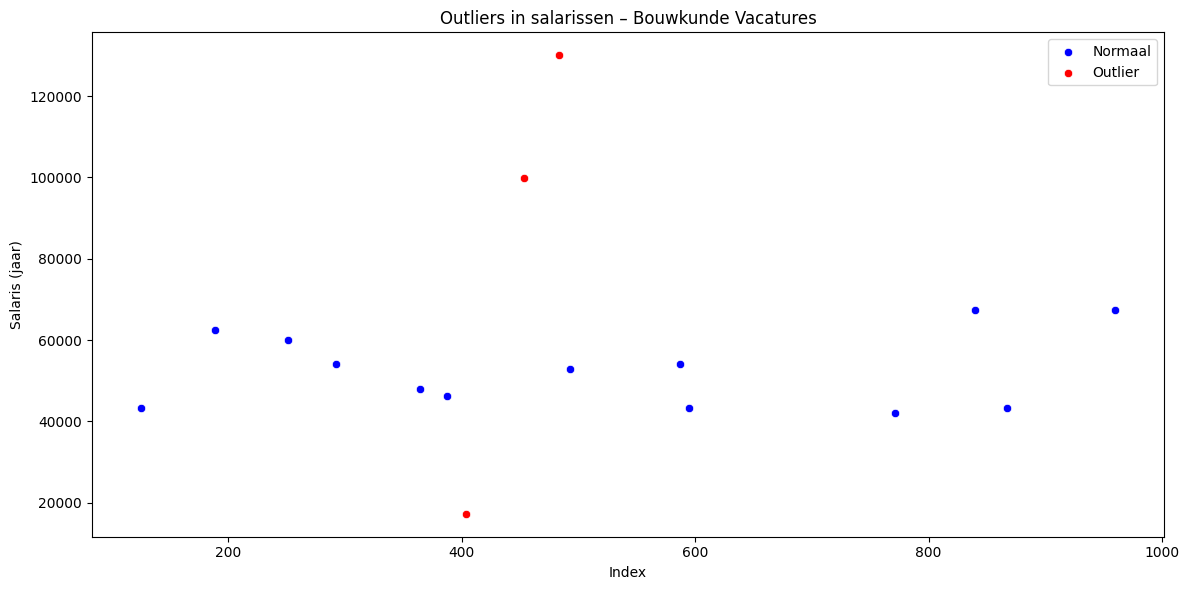

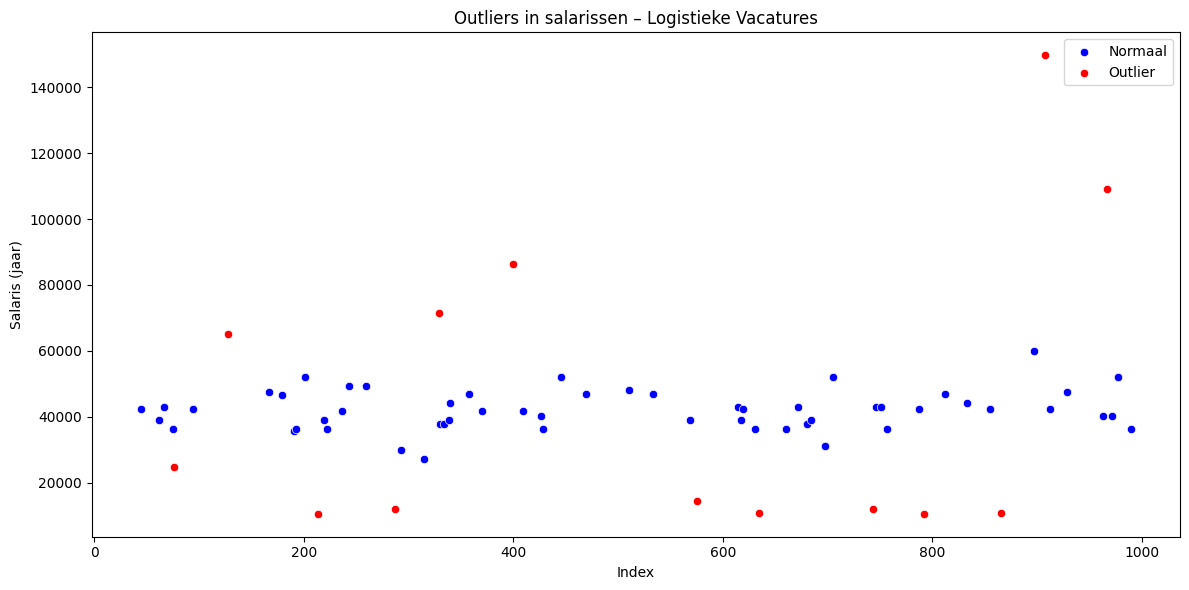

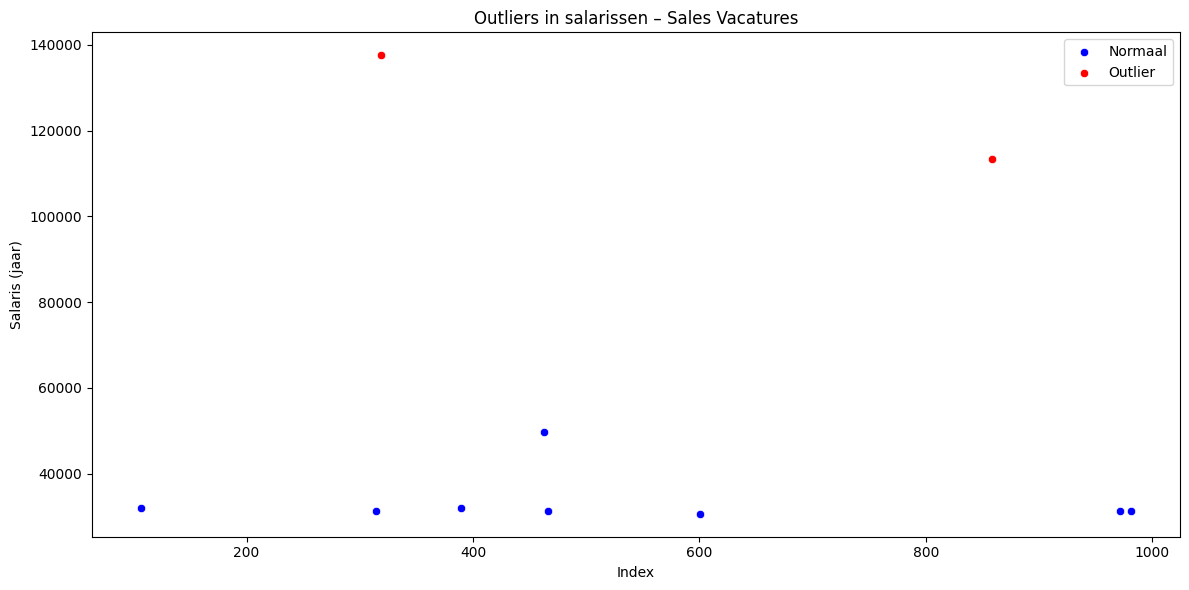

In [ ]:
# Plotten van de outliers per categorie (voorbeeld voor 3 categorieën)
def plot_category_outliers(category_name):
    subset = df_analysis[df_analysis["category"] == category_name].copy()

    # Als er geen data is voor deze categorie dan fout melding
    if subset.empty:
        print(f"Geen data gevonden voor categorie: {category_name}")
        return

    outliers = subset[subset["outlier"] == True]
    normal = subset[subset["outlier"] == False]

    plt.figure(figsize=(12, 6))

    sns.scatterplot(data=normal, x=normal.index, y="salary_mean", color="blue", label="Normaal")
    sns.scatterplot(data=outliers, x=outliers.index, y="salary_mean", color="red",  label="Outlier")

    plt.title(f"Outliers in salarissen – {category_name}")
    plt.xlabel("Index")
    plt.ylabel("Salaris (jaar)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Genereer plots voor drie voorbeeldcategorieën
plot_category_outliers("Bouwkunde Vacatures")
plot_category_outliers("Logistieke Vacatures")
plot_category_outliers("Sales Vacatures")

**Observatie:**  De visualisaties tonen dat elke vacaturecategorie enkele duidelijke outlier bevat: rode punten die sterk afwijken van de normale salariswaarden. Dit laat zien dat binnen alle categorieën uitzonderlijk hoge of lage salarissen voorkomen.

---

**Conclusie**
De originele dataset bevatte meerdere problemen waardoor het analyseteam er niet mee kon werken.
Salarissen stonden in verschillende eenheden (uur, dag, maand), categorieën waren inconsistent of leeg,
en er zaten onrealistische waarden in de data.

Door de data stap voor stap op te schonen is de dataset nu bruikbaar voor analyse:
Alle salarissen zijn omgezet naar een jaarloon
Onrealistische waarden zijn verwijderd
Lege categorieën zijn opgevuld op basis van de jobtitel
Afwijkende salarissen zijn gedetecteerd via IQR en IsolationForest

Het analyseteam kan de opgeschoonde dataset nu gebruiken om betrouwbare conclusies
te trekken over salarissen per functiecategorie.